# Day 17 — Defrost Cycle Energy Simulation
**Mahesha Gonal — Refrigeration Simulation Portfolio**

Models the energy trade-off between frost buildup (which degrades evaporator heat transfer over time) and defrost events (heater + pulldown cost), finds the optimal defrost interval, and quantifies the energy benefit of a simultaneous cooling/defrosting design — directly tied to patent context.

In [1]:
# CELL 1 — Install dependencies (run this first, every time)
!pip install coolprop matplotlib numpy PyGithub -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.0 MB/s eta 0:00:00


In [2]:
# CELL 2 — Imports
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# CELL 3 — System parameters
# Frost buildup degrades evaporator heat transfer the longer the system runs
# without defrosting, forcing the compressor to draw extra power over time.

P_rated = 150.0          # W, nominal compressor running power
frost_coeff = 0.015       # fractional extra power drawn per hour of frost buildup (1.5%/hr)

# Defrost event costs
heater_power = 350.0      # W, resistive defrost heater
heater_duration = 0.25    # hours (15 min)
pulldown_power = 200.0    # W, extra compressor draw while recovering cabinet temp after defrost
pulldown_duration = 1/3   # hours (20 min)

heater_energy_per_event = heater_power * heater_duration            # Wh
pulldown_energy_per_event = pulldown_power * pulldown_duration       # Wh
defrost_energy_per_event = heater_energy_per_event + pulldown_energy_per_event

print(f"Heater energy per defrost event:   {heater_energy_per_event:.1f} Wh")
print(f"Pulldown energy per defrost event: {pulldown_energy_per_event:.1f} Wh")
print(f"Total defrost energy per event:    {defrost_energy_per_event:.1f} Wh")

Heater energy per defrost event:   87.5 Wh
Pulldown energy per defrost event: 66.7 Wh
Total defrost energy per event:    154.2 Wh


In [4]:
# CELL 4 — Energy functions over a sweep of defrost intervals
# Frost energy per day(L) = (24/L cycles) * integral of (P_rated*frost_coeff*t) dt from 0 to L
#                          = 12 * P_rated * frost_coeff * L          (Wh/day)
# Defrost energy per day(L) = (24/L) * defrost_energy_per_event       (Wh/day)

def frost_energy_per_day(L_hours):
    return 12 * P_rated * frost_coeff * L_hours

def defrost_energy_per_day(L_hours):
    cycles_per_day = 24 / L_hours
    return cycles_per_day * defrost_energy_per_event

def total_energy_per_day(L_hours):
    return frost_energy_per_day(L_hours) + defrost_energy_per_day(L_hours)

L_range = np.linspace(2, 24, 500)   # candidate defrost intervals, hours
total_curve = total_energy_per_day(L_range)
frost_curve = frost_energy_per_day(L_range)
defrost_curve = defrost_energy_per_day(L_range)

optimal_idx = np.argmin(total_curve)
L_optimal = L_range[optimal_idx]
E_optimal = total_curve[optimal_idx]

print(f"Optimal defrost interval: {L_optimal:.2f} hours")
print(f"Minimum total defrost-related energy: {E_optimal:.1f} Wh/day")
print(f"  -> Frost penalty at optimum:   {frost_energy_per_day(L_optimal):.1f} Wh/day")
print(f"  -> Defrost cost at optimum:    {defrost_energy_per_day(L_optimal):.1f} Wh/day")

Optimal defrost interval: 11.70 hours
Minimum total defrost-related energy: 632.1 Wh/day
  -> Frost penalty at optimum:   315.9 Wh/day
  -> Defrost cost at optimum:    316.3 Wh/day


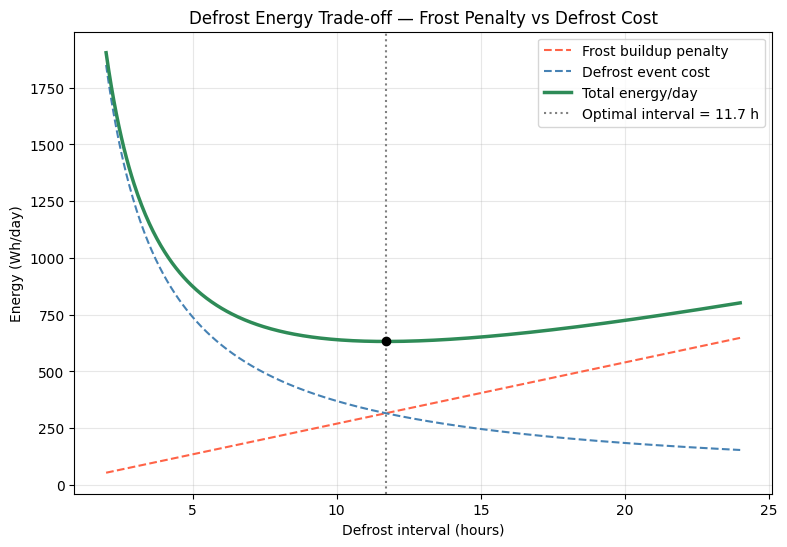

In [5]:
# CELL 5 — Plot the trade-off curve
plt.figure(figsize=(9, 6))
plt.plot(L_range, frost_curve, label="Frost buildup penalty", color="tomato", linestyle="--")
plt.plot(L_range, defrost_curve, label="Defrost event cost", color="steelblue", linestyle="--")
plt.plot(L_range, total_curve, label="Total energy/day", color="seagreen", linewidth=2.5)
plt.axvline(L_optimal, color="gray", linestyle=":", label=f"Optimal interval = {L_optimal:.1f} h")
plt.scatter([L_optimal], [E_optimal], color="black", zorder=5)

plt.xlabel("Defrost interval (hours)")
plt.ylabel("Energy (Wh/day)")
plt.title("Defrost Energy Trade-off — Frost Penalty vs Defrost Cost")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [6]:
# CELL 6 — Patent tie-in: value of simultaneous cooling/defrosting
# A simultaneous-defrost design removes the pulldown penalty entirely, since
# cooling never actually stops during a defrost event in that architecture.

cycles_per_day_optimal = 24 / L_optimal
pulldown_savings_per_day = cycles_per_day_optimal * pulldown_energy_per_event
pct_of_total_saved = pulldown_savings_per_day / E_optimal * 100

print(f"Defrost events per day at optimal interval: {cycles_per_day_optimal:.2f}")
print(f"Pulldown energy eliminated per day: {pulldown_savings_per_day:.1f} Wh")
print(f"That is {pct_of_total_saved:.1f}% of total defrost-related energy waste removed")
print()
print("Interpretation: a sequential-defrost system pays this pulldown cost on every")
print("cycle because cooling stops while defrosting happens. A simultaneous")
print("cooling/defrosting design (per the patent) removes this term structurally —")
print("not by optimizing the timer, but by eliminating the downtime the timer")
print("optimization is trying to work around.")

Defrost events per day at optimal interval: 2.05
Pulldown energy eliminated per day: 136.8 Wh
That is 21.6% of total defrost-related energy waste removed

Interpretation: a sequential-defrost system pays this pulldown cost on every
cycle because cooling stops while defrosting happens. A simultaneous
cooling/defrosting design (per the patent) removes this term structurally —
not by optimizing the timer, but by eliminating the downtime the timer
optimization is trying to work around.


In [ ]:
# FINAL CELL — Push this notebook to GitHub
from github import Github, Auth
from google.colab import userdata, _message
import json

token = userdata.get('GITHUB_TOKEN')
auth = Auth.Token(token)
g = Github(auth=auth)
repo = g.get_repo("MaheshaGonal/refrigeration-simulation-python")

nb_data = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
content = json.dumps(nb_data['ipynb'], indent=1)

filename = "day17_defrost_simulation.ipynb"

try:
    existing = repo.get_contents(filename)
    repo.update_file(filename, "Add Day 17 - defrost cycle energy simulation", content, existing.sha)
    print("Updated existing file on GitHub")
except Exception:
    repo.create_file(filename, "Add Day 17 - defrost cycle energy simulation", content)
    print("Created new file on GitHub")

print("GitHub repo: https://github.com/MaheshaGonal/refrigeration-simulation-python")